# Здесь собраны все задания, ответ на которые не был принят, при кореектной реализации

# Упражнение 2.3

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

print("numpy version:", np.__version__)
print("cv2 version:", cv2.__version__)

numpy version: 2.2.6
cv2 version: 4.13.0


1.5
360


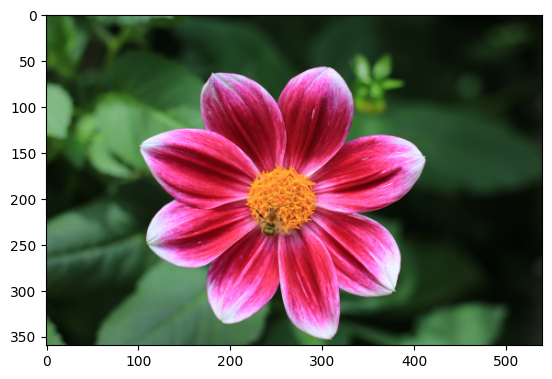

In [5]:
img_path = "data/ex2/nicolas-reymond-tNm6DL_nO-o-unsplash.jpg"

img = cv2.imread(img_path)

target_width = 540
target_height = int(target_width / img.shape[1] * img.shape[0])
print(img.shape[1] / img.shape[0])
print(target_height)

res = cv2.resize(img, (target_width, target_height), interpolation = cv2.INTER_AREA)
res = cv2.cvtColor(res, cv2.COLOR_BGR2RGB)
plt.imshow(res)

In [6]:
cv2.imwrite("blabla.jpg", res)
!ls -l blabla.jpg

-rw-r--r--  1 joulin  staff  61495 May 27 15:49 blabla.jpg


In [7]:
os.path.getsize('blabla.jpg') # Этот ответ система не принимет

61495

In [ ]:
# Попытка: https://lms.itmo.ru/mod/quiz/review.php?attempt=848796&cmid=27499

# Упражнение 4.2

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

print("numpy version:", np.__version__)
print("cv2 version:", cv2.__version__)

numpy version: 2.2.6
cv2 version: 4.13.0


In [13]:
image_path = "data/ex3/bird-2847799_1280.jpg"

img = cv2.imread(image_path)

laplacian_b = cv2.Laplacian(img[:, :, 0], -1)
laplacian_g = cv2.Laplacian(img[:, :, 1], -1)
laplacian_r = cv2.Laplacian(img[:, :, 2], -1)
laplacian_b = np.abs(laplacian_b)
laplacian_g = np.abs(laplacian_g)
laplacian_r = np.abs(laplacian_r)

sum_laplace = np.sum(laplacian_b) + np.sum(laplacian_g) + np.sum(laplacian_r)
print(f"Оператор Лапласа: {sum_laplace:.2f}")

Оператор Лапласа: 12529133.00


In [19]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(gray, 100, 200) # границы для детектора Canny не заданы в задании, приходится брать стандартные

sum_canny = np.sum(edges)
print(f"Детектор Канни: {sum_canny}") # Этот ответ система не принимет

Детектор Канни: 8055960


In [ ]:
# Попытка https://lms.itmo.ru/mod/quiz/review.php?attempt=843726&cmid=27507

# Упражнение 9

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

import keras
from keras.layers import Dense
from keras import Model
from keras import optimizers
from keras.optimizers import Adam
from keras.applications.vgg16 import VGG16


vggmodel = VGG16(weights = 'imagenet', include_top = True)

In [ ]:
for layers in (vggmodel.layers)[:15]:
    layers.trainable = False

X = vggmodel.layers[-2].output
predictions = Dense(2, activation = "softmax")(X)
model_final = Model(inputs = vggmodel.input, outputs = predictions)

opt = Adam(learning_rate = 0.0001)
model_final.compile(loss = keras.losses.categorical_crossentropy, optimizer = opt, metrics=["accuracy"])
model_final.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │         8,194 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,268,738 (512.19 MB)

 Trainable params: 126,633,474 (483.07 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [ ]:
!unzip Comp_Vision_Task_3_model.zip

Archive:  Comp_Vision_Task_3_model.zip
   creating: Comp_Vision_Task_3_model/
  inflating: __MACOSX/._Comp_Vision_Task_3_model  
  inflating: Comp_Vision_Task_3_model/ieeercnn_vgg16_1.h5  
  inflating: __MACOSX/Comp_Vision_Task_3_model/._ieeercnn_vgg16_1.h5  
  inflating: Comp_Vision_Task_3_model/Comp_Vision_Task_3_model.json  
  inflating: __MACOSX/Comp_Vision_Task_3_model/._Comp_Vision_Task_3_model.json  


In [ ]:
model_final.load_weights('Comp_Vision_Task_3_model/ieeercnn_vgg16_1.h5')

Process regions: 294
2/2 ━━━━━━━━━━━━━━━━━━━━ 44s 21s/step
Found in batch: 0
2/2 ━━━━━━━━━━━━━━━━━━━━ 43s 21s/step
Found in batch: 1
2/2 ━━━━━━━━━━━━━━━━━━━━ 43s 21s/step
Found in batch: 0
2/2 ━━━━━━━━━━━━━━━━━━━━ 43s 22s/step
Found in batch: 1
2/2 ━━━━━━━━━━━━━━━━━━━━ 26s 5s/step
Found in batch: 0


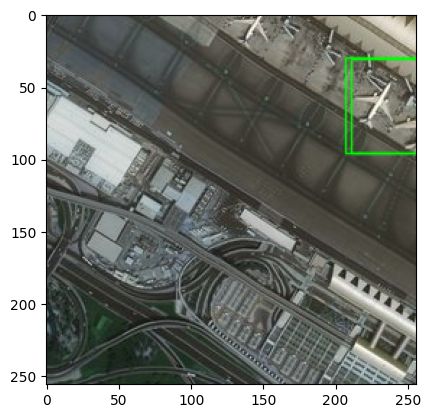

In [ ]:
cv2.setUseOptimized(True);
ss = cv2.ximgproc.segmentation.createSelectiveSearchSegmentation()

img = cv2.imread('/content/428451.jpg')
ss.setBaseImage(img)
ss.switchToSelectiveSearchFast()
ssresults = ss.process()
imout = img.copy()

print("Process regions:", len(ssresults))

results = []
batch_size = 64
batch_params = []
batch = []

for e,result in enumerate(ssresults):
    x,y,w,h = result
    timage = imout[y: y + h,x: x + w]
    resized = cv2.resize(timage, (224,224), interpolation = cv2.INTER_AREA)
    batch_params.append(list(result))
    batch.append(resized)

    if len(batch) >= batch_size or e == len(ssresults) - 1:
        batch, batch_params = np.array(batch), np.array(batch_params)
        out = model_final.predict(batch)
        probas = out[:, 0]
        mask = probas > 0.65
        print("Found in batch:", mask.sum())

        for selected_param, proba in zip(batch_params[mask], probas[mask]):
            x,y,w,h = selected_param
            cv2.rectangle(imout, (x, y), (x + w, y + h), (0, 255, 0), 1, cv2.LINE_AA)
            results.append([proba,x,y,w,h])

        batch, batch_params = [], []

plt.figure()
plt.imshow(imout)

In [ ]:
results = sorted(results, key=lambda x: x[0], reverse=True)
results

[[np.float32(0.81470615),
  np.int32(207),
  np.int32(30),
  np.int32(49),
  np.int32(66)],
 [np.float32(0.67798835),
  np.int32(211),
  np.int32(31),
  np.int32(45),
  np.int32(65)]]

Не принято 3 / 11 ответов, при этом в 4 разделе x, y и ширина верные, а не высота и вероятность, по мнению системы - нет. 

Это может означать только то, что cv2 в данной, более новой версии, генерирует немного другие регионы интереса, чем в старой версии, когда пислаось задание

# Упраженeние 12.1

In [2]:
import cv2
import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt

print("Torch version:", torch.__version__)

Torch version: 2.12.0


In [3]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(100, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 1024),
            nn.ReLU(),
            nn.Linear(1024, 784),
            nn.Tanh(),
        )

    def forward(self, x):
        output = self.model(x)
        output = output.view(x.size(0), 1, 28, 28)
        return output

In [4]:
device = torch.device('cpu')
model = torch.load('data/ex12/generator_20', weights_only=False, map_location=device)
model = model.eval().to(device)
model

Generator(
  (model): Sequential(
    (0): Linear(in_features=100, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=1024, bias=True)
    (5): ReLU()
    (6): Linear(in_features=1024, out_features=784, bias=True)
    (7): Tanh()
  )
)

In [5]:
latent_tensor = torch.load('data/ex12/Comp_Vision_Task_6_Test_file_12.pt', map_location=device)
latent_tensor.shape, latent_tensor.device

(torch.Size([1, 100]), device(type='cpu'))

(28, 28)


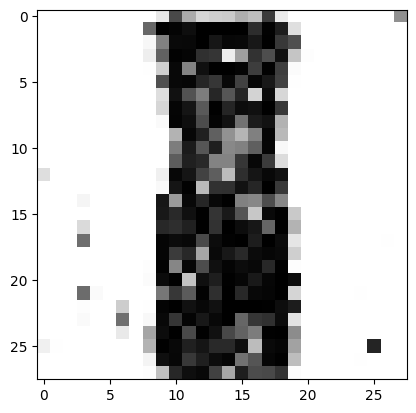

In [6]:
gen_image = model(latent_tensor)
gen_image = gen_image.cpu().detach().numpy()[0, 0]

print(gen_image.shape)
plt.imshow(gen_image, cmap="gray_r")

Средняя интенсивность: 74.071


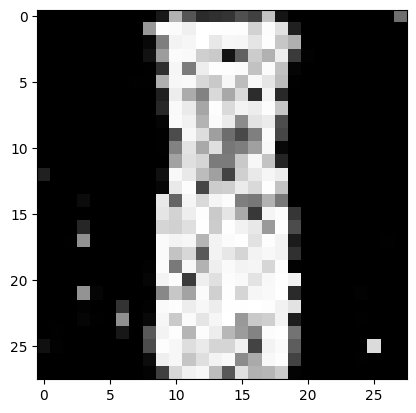

In [8]:
# Корректный вариант трансформации из [-1, 1] -> [0, 255]

gen_image_norm = np.round((gen_image + 1) / 2 * 255)

print("Средняя интенсивность:", round(float(np.mean(gen_image_norm)), 3))

plt.imshow(gen_image_norm, 'gray')

In [ ]:
# Ответ не принимается, попытка https://lms.itmo.ru/mod/quiz/review.php?attempt=848636&cmid=19991

Средняя интенсивность: 74.11


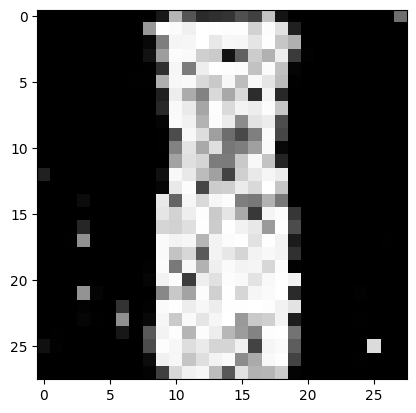

In [9]:
# В задании указано MinMax трансформация, что только запутывает, но вот его реализация тоже

gen_image_norm = np.round((gen_image - gen_image.min()) / (gen_image.max() - gen_image.min()) * 255)

print("Средняя интенсивность:", round(float(np.mean(gen_image_norm)), 3))

plt.imshow(gen_image_norm, 'gray')

In [ ]:
# Ответ не принимается, попытка https://lms.itmo.ru/mod/quiz/review.php?attempt=848663&cmid=19991

# Упраженeние 12.2

In [1]:
!git clone https://github.com/junyanz/pytorch-CycleGAN-and-pix2pix

Cloning into 'pytorch-CycleGAN-and-pix2pix'...
remote: Enumerating objects: 2619, done.
remote: Total 2619 (delta 0), reused 0 (delta 0), pack-reused 2619 (from 1)
Receiving objects: 100% (2619/2619), 8.24 MiB | 17.11 MiB/s, done.
Resolving deltas: 100% (1654/1654), done.


In [2]:
import os
os.chdir('pytorch-CycleGAN-and-pix2pix/')

In [6]:
# Файла requirements.txt БОЛЬШЕ НЕТ в исходном репозитории с 31 июля 2025 г., он заменён на environment.yml
!pip install dominate>=2.8.0 Pillow>=10.0.0 wandb>=0.16.0

In [4]:
!bash ./scripts/download_cyclegan_model.sh style_monet

Note: available models are apple2orange, orange2apple, summer2winter_yosemite, winter2summer_yosemite, horse2zebra, zebra2horse, monet2photo, style_monet, style_cezanne, style_ukiyoe, style_vangogh, sat2map, map2sat, cityscapes_photo2label, cityscapes_label2photo, facades_photo2label, facades_label2photo, iphone2dslr_flower
Specified [style_monet]
for details.

--2026-05-27 12:07:09--  http://efrosgans.eecs.berkeley.edu/cyclegan/pretrained_models/style_monet.pth
Resolving efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)... 128.32.244.190
Connecting to efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)|128.32.244.190|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 45575747 (43M)
Saving to: ‘./checkpoints/style_monet_pretrained/latest_net_G.pth’

./checkpoints/style 100%[===================>]  43.46M  28.5MB/s    in 1.5s    

2026-05-27 12:07:10 (28.5 MB/s) - ‘./checkpoints/style_monet_pretrained/latest_net_G.pth’ saved [45575747/45575747]



In [7]:
os.makedirs('/content/ex12_test/', exist_ok=True)

In [8]:
!python test.py --dataroot '/content/ex12_test/' --name style_monet_pretrained --model test  --no_dropout

----------------- Options ---------------
             aspect_ratio: 1.0                           
               batch_size: 1                             
          checkpoints_dir: ./checkpoints                 
                crop_size: 256                           
                 dataroot: /content/ex12_test/           	[default: None]
             dataset_mode: single                        
                direction: AtoB                          
          display_winsize: 256                           
                    epoch: latest                        
                     eval: False                         
                init_gain: 0.02                          
                init_type: normal                        
                 input_nc: 3                             
                  isTrain: False                         	[default: None]
                load_iter: 0                             	[default: 0]
                load_size: 256             

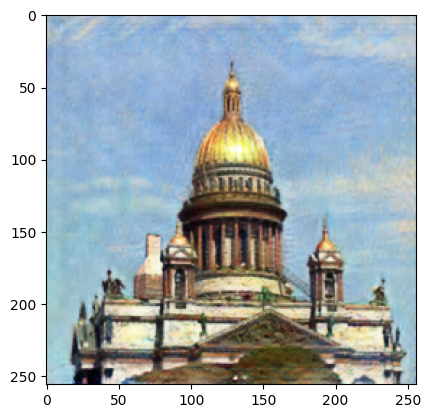

In [9]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('/content/pytorch-CycleGAN-and-pix2pix/results/style_monet_pretrained/test_latest/images/architecture-995613_1280_fake.png')
plt.imshow(img[:, :, ::-1])

In [11]:
import numpy as np
np.mean(img)

np.float64(159.69244893391928)

In [ ]:
# Ответ не принят, попытка https://lms.itmo.ru/mod/quiz/review.php?attempt=848693&cmid=27526

# Важные моменты по другим заданиям

In [ ]:
В задании 7 требууется некорретная формула контрастности, которая также некорректно была дана и в лекции

In [ ]:
# Корректная реализация
def contrast(image, p):
    image = image / 255.
    if p > 0:
        image = (image - 0.5) / (1 - p) + 0.5
    else:
        image = (image - 0.5) * (1 - p) + 0.5
    image = np.round(np.clip(image, 0, 1) * 255).astype(np.uint8)
    return image

# Некорректная реализация! но при этом ответ только от неё принимается как правильный
def contrast(image, p):
    image = image / 255.
    if p > 0:
        image = (image - 0.5) / (1 - p) # нет обратного смещения +0.5
    else:
        image = (image - 0.5) * (1 - p) # нет обратного смещения +0.5
    image = np.round(np.clip(image, 0, 1) * 255).astype(np.uint8)
    return image

In [ ]:
# Даже есть проверить и отразить как это влияет на картинку сразу замтно, что так не должно быть, картинка становится очень тёмной

26.956039780471183
26.585137388045172


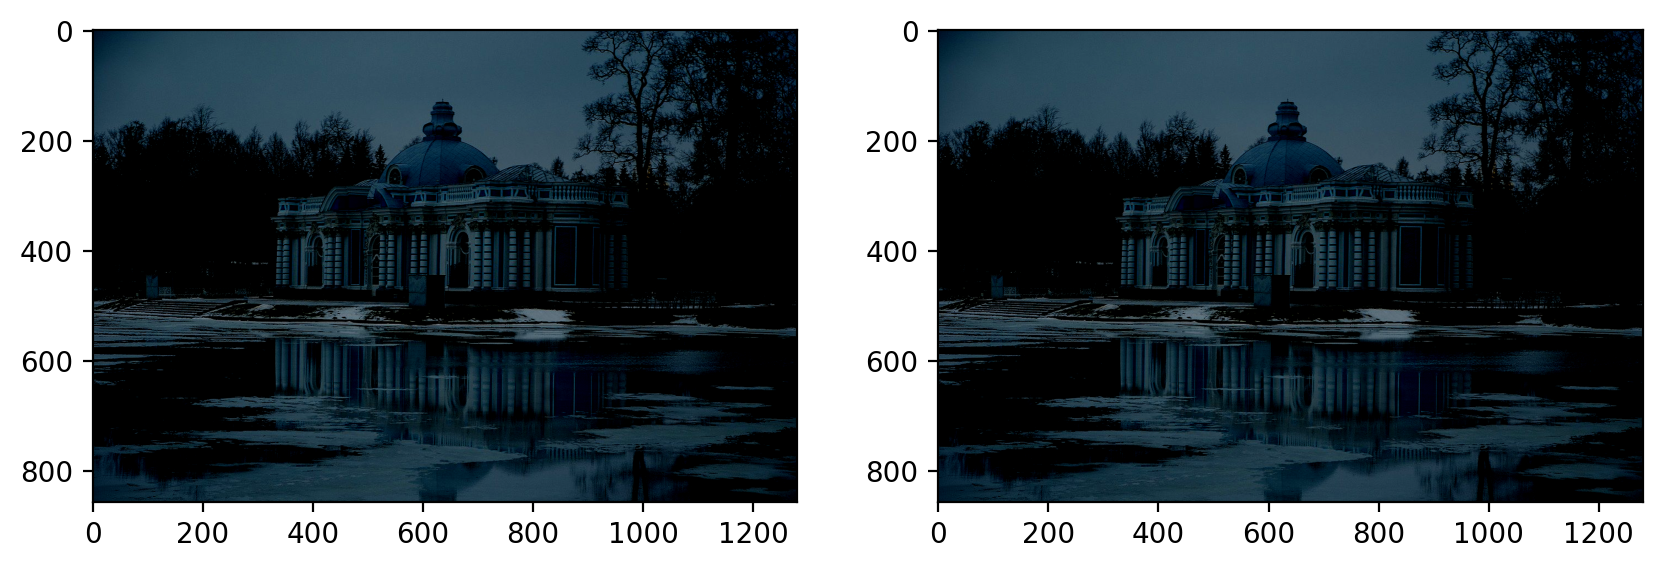

In [180]:
def contrast(image, p):
    image = image / 255.
    if p > 0:
        image = (image - 0.5) / (1 - p) # + 0.5
    else:
        image = (image - 0.5) * (1 - p) # + 0.5
    image = np.round(np.clip(image, 0, 1) * 255).astype(np.uint8)
    return image

img_result = contrast(img, -0.3)
print(np.mean(img_result))

img_result2 = contrast(img, 0.22)
print(np.mean(img_result2))

_, axs = plt.subplots(1, 2, figsize=(10, 16))
axs[0].imshow(img_result[:, :, ::-1])
axs[1].imshow(img_result2[:, :, ::-1])